
# RoboterProgrammierung Projektaufgabe — Roundtrip-Path 

**done:**

**1. a)**
- **a.** Startposition definieren
- **b.** Mehrere Endpositionen definieren
- **c.** Interface wie andere Bahnplaner (basiert auf `PlanerBase`)
- **d.** Bahnplan algo wählbar und custom config uebergebbar [PRM, LazyPRM, visibility PRM, RRT, Astar]
- **e.** TSP christofides loesung implementiert mit NetworkX

**todo:**
- nothing left todo

![My figure](./images/gmapsroundtripbsp.png)

# https://github.com/OsmanMarangoz/Roundtrip-Path-WS25-26


In [58]:
import sys
sys.path.append(".")

import matplotlib.pyplot as plt
%matplotlib inline

from shapely.geometry import Point, LineString
from shapely import plotting
from IPEnvironment import CollisionChecker
from IPRoundtripPlanner import RoundtripPlanner

#Path planer hier importieren
from IPLazyPRM import LazyPRM
from IPBasicPRM import BasicPRM
from IPRRT import RRTSimple
from IPAStar import AStar
from IPVisibilityPRM import VisPRM
from IPRoundtripPlanner import RoundtripPlanner


In [59]:
PLANNERS = {
    "LazyPRM": {
        "config": {
            "initialRoadmapSize": 40,
            "updateRoadmapSize": 20,
            "kNearest": 5,
            "maxIterations": 40
        },
        "class": LazyPRM
    },
    "BasicPRM": {
        "config": {
            "radius": 5.0,             # Suchradius für Nachbarn
            "numNodes": 300,           # Anzahl der zu generierenden Knoten
            "useKDTree": True          # KDTree für schnelle Nachbarsuche (optional)
        },
        "class": BasicPRM
    },
    "RRTSimple": {
        "config": {
            "numberOfGeneratedNodes": 500,
            "testGoalAfterNumberOfNodes": 10
        },
        "class": RRTSimple
    },
    "VisPRM": {
        "config": {
            "ntry": 40                 # Anzahl Versuche für Roadmap-Erstellung
        },
        "class": VisPRM,
        },
    "AStar": {
        "config": {
            "w": 0.5,                  # Grid-Auflösung (Zellenbreite)
            "heuristic": "euclid"      # Heuristik: "euclid" oder "manhattan"
        },
        "class": AStar,
        },
}

# NUTZER HIER PLANER AUSWÄHLEN!
# Einfach den Namen des Planers als String eingeben:
# (Config der planner konnen im dictionary oben angepasst werden.)

Selected_Planner = "LazyPRM"

In [60]:
# Berni du kannst deine szenen hier definieren
scene = dict()
scene["obs1"] = LineString([(8, 5), (8, 15)]).buffer(1.0)
scene["obs2"] = LineString([(14, 8), (14, 18)]).buffer(1.0)
scene["obs3"] = Point([11, 11]).buffer(1.5)

# CollisionChecker erstellen
environment = CollisionChecker(scene, limits=[[0, 22], [0, 22]])

# Basis-Planer mit ihrer config initialisieren
base_planner = PLANNERS[Selected_Planner]["class"](environment)
config = PLANNERS[Selected_Planner]["config"]

start = [3, 3]

goals = [
    [19, 3],
    [19, 19],
    [3, 19],
    [1,1],
    [15,13],
    [4, 5],
    [9,9],
    [12,5],
    [3, 5],
    [3, 8]
]



a) Startposition: [3, 3]

b) Endpositionen (10 Ziele):
   Ziel 1: [19, 3]
   Ziel 2: [19, 19]
   Ziel 3: [3, 19]
   Ziel 4: [1, 1]
   Ziel 5: [15, 13]
   Ziel 6: [4, 5]
   Ziel 7: [9, 9]
   Ziel 8: [12, 5]
   Ziel 9: [3, 5]
   Ziel 10: [3, 8]


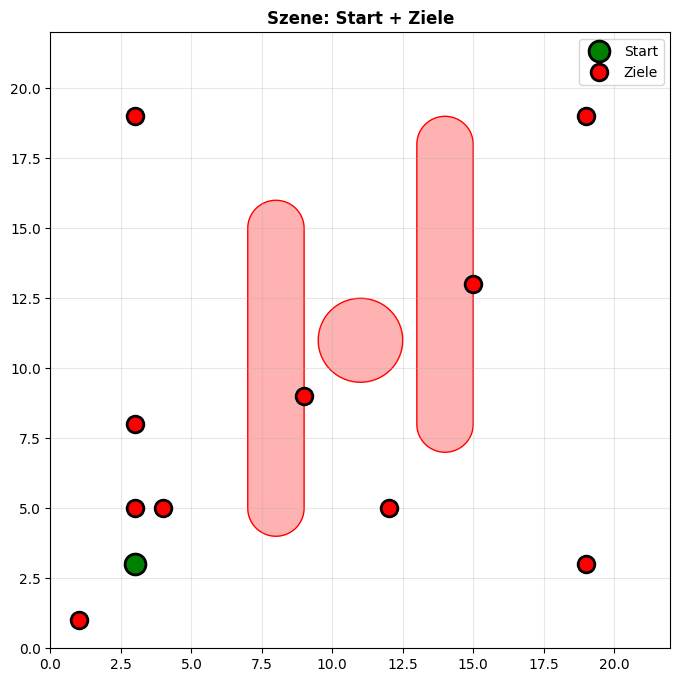

In [61]:
print(f"\na) Startposition: {start}")
print(f"\nb) Endpositionen ({len(goals)} Ziele):")
for i, goal in enumerate(goals, 1):
    print(f"   Ziel {i}: {goal}")

# Szene visualisieren
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim([0, 22])
ax.set_ylim([0, 22])
environment.drawObstacles(ax)

# Start und Ziele markieren
ax.plot(start[0], start[1], 'go', markersize=15, label='Start',
        markeredgecolor='black', markeredgewidth=2)
for i, goal in enumerate(goals):
    ax.plot(goal[0], goal[1], 'ro', markersize=12,
            label='Ziele' if i == 0 else '',
            markeredgecolor='black', markeredgewidth=2)

ax.legend()
ax.set_title("Szene: Start + Ziele", fontweight='bold')
ax.grid(True, alpha=0.3)
plt.show()

In [62]:
# RoundtripPlanner erstellen
roundtrip = RoundtripPlanner(environment, base_planner)

# config ist bereits definiert mit allen LazyPRM Parametern
path = roundtrip.planPath([start], goals, config)

print(f"\nPfad mit {len(path)} Punkten erstellt")
print(f"  Start: {path[0]}")
print(f"  Ende:  {path[-1]}")


Path Planing gestartet mit LazyPRM

Start: [3, 3]
Goals: 8 Ziele
  - Goal 1: [19, 3]
  - Goal 2: [19, 19]
  - Goal 3: [3, 19]
  - Goal 4: [1, 1]
  - Goal 5: [4, 5]
  - Goal 6: [12, 5]
  - Goal 7: [3, 5]
  - Goal 8: [3, 8]
  TSP-Lösung (Christofides): Approximierte Distanz = 77.60
  Optimierte Reihenfolge: Start → [1, 1] → [3, 5] → [3, 8] → [3, 19] → [19, 19] → [12, 5] → [19, 3] → [4, 5] → Start

→ Plane Segment 1/9: [3, 3] → [1, 1]
Pfad gefunden: 3 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 3 Punkte

→ Plane Segment 2/9: [1, 1] → [3, 5]
Pfad gefunden: 4 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 4 Punkte

→ Plane Segment 3/9: [3, 5] → [3, 8]
Pfad gefunden: 3 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 3 Punkte

→ Plane Segment 4/9: [3, 8] → [3, 19]
Pfad gefunden: 3 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 3 Punkte

→ Plane Segment 5/9: [3, 19] → [19, 19]
Pfad gefunden: 5 Punkte (im Versuch 1)
Konvertiert zu Koordinaten: 5 Punkte

→ Plane Segment 6/9: [19, 1

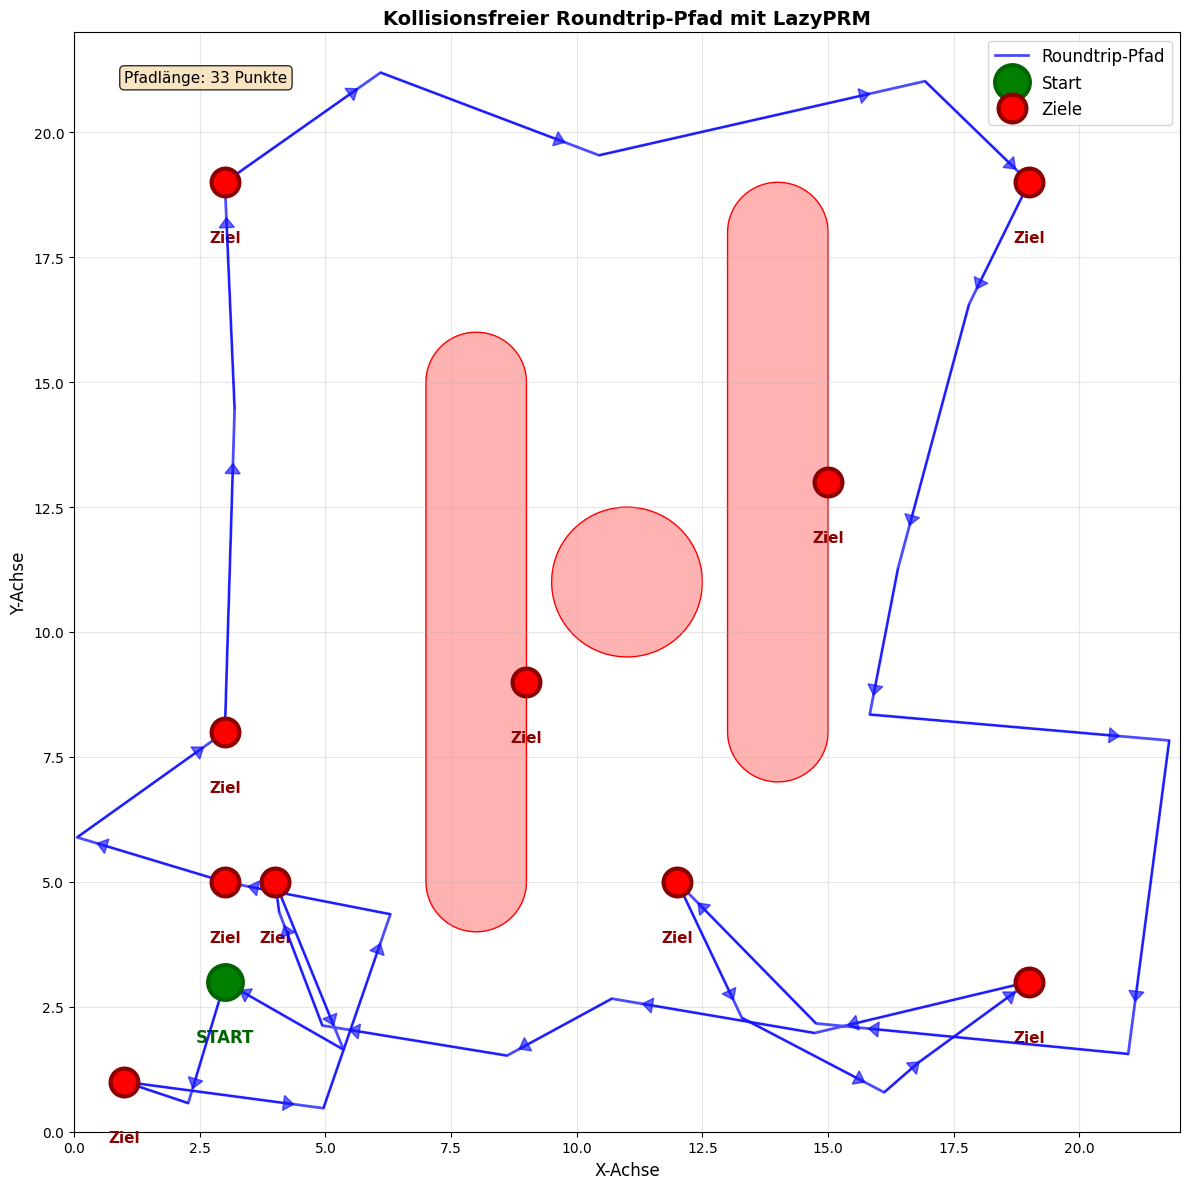

In [63]:
# Visualisierung des Roundtrip-Pfads
fig, ax = plt.subplots(figsize=(12, 12))
ax.set_xlim([0, 22])
ax.set_ylim([0, 22])

# Hindernisse zeichnen
environment.drawObstacles(ax)

# Pfad als dicke blaue Linie zeichnen
x_coords = [p[0] for p in path]
y_coords = [p[1] for p in path]
ax.plot(x_coords, y_coords, 'b-', linewidth=2, alpha=0.7, label='Roundtrip-Pfad', zorder=5)

# Richtungspfeile hinzufügen
step = max(1, len(path) // 20)
for i in range(0, len(path) - 1, step):
    dx = x_coords[i+1] - x_coords[i]
    dy = y_coords[i+1] - y_coords[i]
    ax.arrow(x_coords[i], y_coords[i], dx*0.8, dy*0.8,
             head_width=0.3, head_length=0.2, fc='blue', ec='blue',
             alpha=0.6, zorder=6)

# Start markieren (GRÜN)
ax.plot(start[0], start[1], 'go', markersize=25, label='Start',
        markeredgecolor='darkgreen', markeredgewidth=3, zorder=10)
ax.text(start[0], start[1]-1.2, 'START', fontsize=12, fontweight='bold',
        ha='center', color='darkgreen')

# Ziele markieren (ROT)
for i, goal in enumerate(goals, 1):
    ax.plot(goal[0], goal[1], 'ro', markersize=20,
            label='Ziele' if i == 1 else '',
            markeredgecolor='darkred', markeredgewidth=3, zorder=10)
    ax.text(goal[0], goal[1]-1.2, 'Ziel', fontsize=11, fontweight='bold',
            ha='center', color='darkred')

# Pfad-Statistiken
ax.text(1, 21, f'Pfadlänge: {len(path)} Punkte', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.legend(loc='upper right', fontsize=12)
ax.set_title(f"Kollisionsfreier Roundtrip-Pfad mit {PLANNERS[Selected_Planner]['class'].__name__}", fontsize=14, fontweight='bold')
ax.set_xlabel('X-Achse', fontsize=12)
ax.set_ylabel('Y-Achse', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


![My figure](./images/UMLDIAGRAMM1.png)